In [1]:
!git clone https://github.com/210108cse-hash/CNN-CIFAR10-Vehicles-Animals.git
%cd CNN-CIFAR10-Vehicles-Animals


Cloning into 'CNN-CIFAR10-Vehicles-Animals'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 23 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 2.55 MiB | 7.43 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/CNN-CIFAR10-Vehicles-Animals


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [4]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])


In [5]:
train_full = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_full  = CIFAR10(root='./data', train=False, download=True, transform=transform)


100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


In [6]:
selected_classes = {
    1: "car",
    2: "bird",
    3: "cat",
    5: "dog"
}

def filter_dataset(dataset):
    indices = [i for i, (_, label) in enumerate(dataset) if label in selected_classes]
    return Subset(dataset, indices)

train_dataset = filter_dataset(train_full)
test_dataset  = filter_dataset(test_full)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

class_names = list(selected_classes.values())


In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [8]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [9]:
epochs = 10
train_loss, val_loss = [], []
train_acc, val_acc = [], []

for epoch in range(epochs):
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        labels = torch.tensor(
            [list(selected_classes.keys()).index(l.item()) for l in labels]
        ).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss.append(loss_sum / len(train_loader))
    train_acc.append(100 * correct / total)

    model.eval()
    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            labels = torch.tensor(
                [list(selected_classes.keys()).index(l.item()) for l in labels]
            ).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss.append(loss_sum / len(test_loader))
    val_acc.append(100 * correct / total)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Acc: {train_acc[-1]:.2f}% | "
          f"Val Acc: {val_acc[-1]:.2f}%")


Epoch 1/10 | Train Acc: 61.83% | Val Acc: 68.80%
Epoch 2/10 | Train Acc: 72.03% | Val Acc: 71.25%
Epoch 3/10 | Train Acc: 76.17% | Val Acc: 73.72%
Epoch 4/10 | Train Acc: 79.55% | Val Acc: 76.22%
Epoch 5/10 | Train Acc: 82.11% | Val Acc: 76.88%
Epoch 6/10 | Train Acc: 84.79% | Val Acc: 76.65%
Epoch 7/10 | Train Acc: 87.43% | Val Acc: 76.47%
Epoch 8/10 | Train Acc: 89.81% | Val Acc: 77.05%
Epoch 9/10 | Train Acc: 92.19% | Val Acc: 76.97%
Epoch 10/10 | Train Acc: 93.34% | Val Acc: 76.97%


In [10]:
os.makedirs("model", exist_ok=True)
torch.save(model.state_dict(), "model/210108.pth")


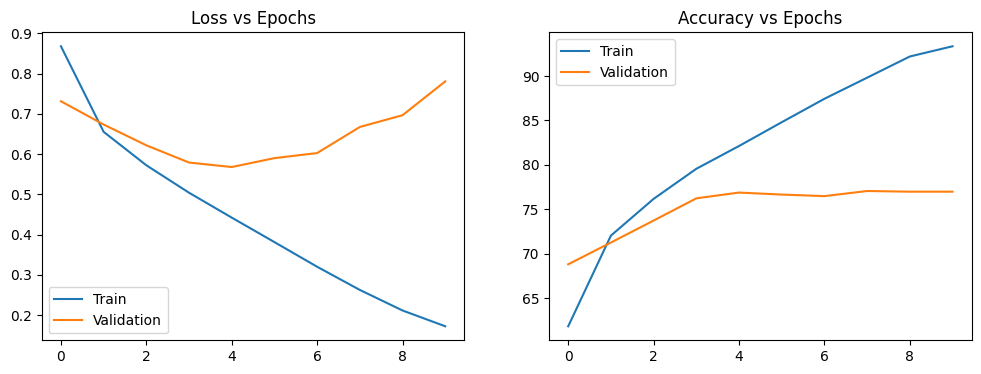

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.title("Loss vs Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()


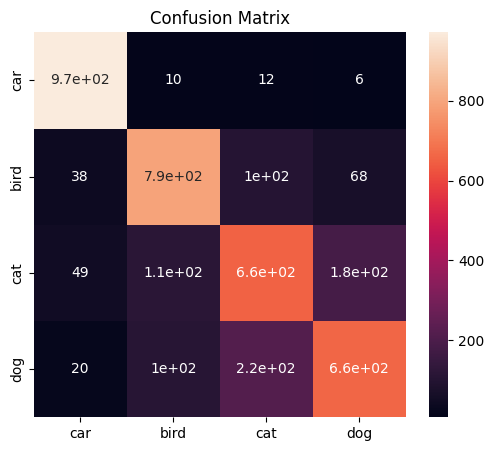

In [12]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = torch.tensor(
            [list(selected_classes.keys()).index(l.item()) for l in labels]
        )

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()


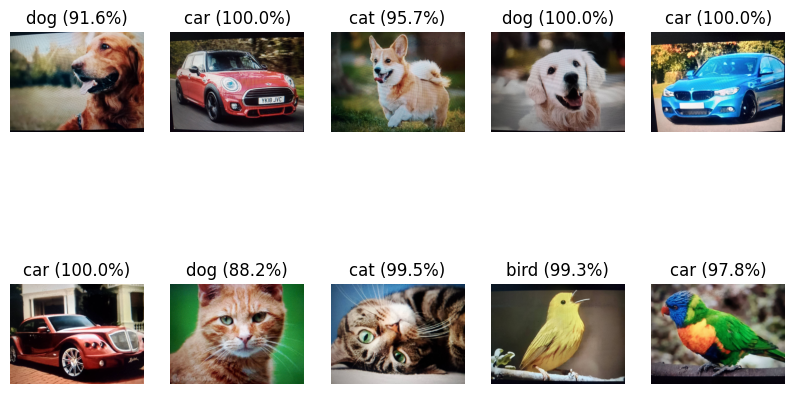

In [13]:
img_dir = "dataset"
plt.figure(figsize=(10,6))

model.eval()
for i, img_name in enumerate(os.listdir(img_dir)):
    img = Image.open(os.path.join(img_dir, img_name)).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_t)
        prob = torch.softmax(output, dim=1)
        conf, pred = torch.max(prob, 1)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"{class_names[pred]} ({conf.item()*100:.1f}%)")
    plt.axis("off")

plt.show()


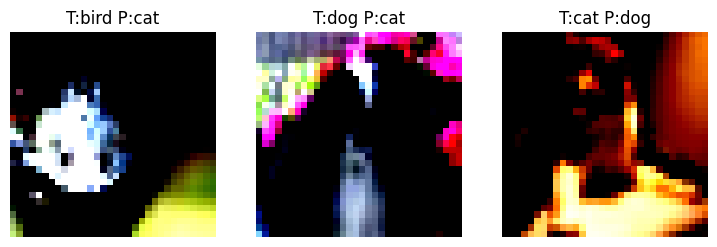

In [14]:
errors = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = torch.tensor(
            [list(selected_classes.keys()).index(l.item()) for l in labels]
        )

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                errors.append((images[i].cpu(), labels[i], preds[i]))

plt.figure(figsize=(9,3))
for i in range(3):
    img, t, p = errors[i]
    plt.subplot(1,3,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"T:{class_names[t]} P:{class_names[p]}")
    plt.axis("off")
plt.show()


In [15]:
# from google.colab import files
# files.download("model/210108.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>